# 👩‍🎓 Student Dashboard
### A deep dive into enrollment patterns, course preferences, and student demographics.

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

PALETTE = {
    'primary':   '#2563EB',
    'secondary': '#10B981',
    'accent':    '#F59E0B',
    'danger':    '#EF4444',
    'gray':      '#6B7280',
    'light':     '#F3F4F6',
    'courses': px.colors.qualitative.Pastel,
}

def clean_layout(fig, title='', height=400):
    fig.update_layout(
        title=dict(text=title, font=dict(size=15, color='#111827'), x=0),
        height=height,
        margin=dict(l=20, r=20, t=50, b=20),
        paper_bgcolor='white',
        plot_bgcolor='white',
        font=dict(family='Arial', size=12, color='#374151'),
        legend=dict(orientation='h', yanchor='bottom', y=1.02,
                    xanchor='right', x=1, bgcolor='rgba(0,0,0,0)',
                    font=dict(size=11)),
        xaxis=dict(showgrid=False, linecolor='#E2E8F0', tickfont=dict(size=11)),
        yaxis=dict(gridcolor='#F3F4F6', linecolor='#E2E8F0', tickfont=dict(size=11)),
    )
    return fig

print('✅ Libraries loaded.')

✅ Libraries loaded.


## 📂 1. Load & Prepare Data

In [2]:
students_raw = pd.read_csv("../data/students.csv")

students_raw['enrollment_date']  = pd.to_datetime(students_raw['enrollment_date'], dayfirst=False, errors='coerce')
students_raw['enrollment_month'] = students_raw['enrollment_date'].dt.to_period('M').astype(str)

students = students_raw.copy()
print(f'Students: {len(students)} rows  |  Columns: {list(students.columns)}')

Students: 200 rows  |  Columns: ['student_id', 'student_name', 'age', 'education_level', 'course', 'duration', 'mode', 'enrollment_date', 'internship', 'batch_id', 'enrollment_month']


In [12]:
students.head()

,student_id,student_name,age,education_level,course,duration,mode,enrollment_date,internship,batch_id,enrollment_month
0,STU0001,Kiran,35,Working Professional,MERN Stack Development,6 Months,Online,2025-01-02,No,B04,2025-01
1,STU0002,Tanya,19,UG,Data Science with Python,1 Month,Online,2025-01-02,FGYP Internship,B02,2025-01
2,STU0003,Faisal,34,Working Professional,Data Science with Python,3 Months,Offline,2025-01-02,No,A03,2025-01
3,STU0004,Ajay,18,UG,Python Full Stack Development,3 Months,Offline,2025-01-02,No,A07,2025-01
4,STU0005,Rahul,22,PG,MERN Stack Development,6 Months,Offline,2025-01-03,No,A01,2025-01


## 🎛️ 2. Optional Filters

In [3]:
FILTER_COURSES = []   # e.g. ['Data Science with Python', 'DevOps']
FILTER_MODES   = []   # e.g. ['Online']
FILTER_EDU     = []   # e.g. ['UG', 'PG']

def apply(df, col, vals):
    return df[df[col].isin(vals)] if vals else df

students = apply(apply(apply(students_raw, 'course', FILTER_COURSES), 'mode', FILTER_MODES), 'education_level', FILTER_EDU)
print(f'Filtered → Students: {len(students)}')

Filtered → Students: 200


## 📊 3. Student KPIs

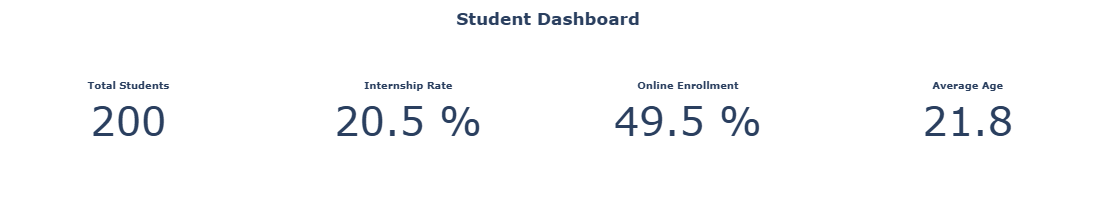

In [14]:
import plotly.graph_objects as go

# ── Data ──
total_students = len(students)

internship_pct = round(
    (students['internship'] != 'No').sum() / total_students * 100, 1
) if total_students else 0

online_pct = round(
    (students['mode'] == 'Online').sum() / total_students * 100, 1
) if total_students else 0

avg_age = round(students['age'].mean(), 1) if 'age' in students.columns else 0

# ── Figure ──
fig = go.Figure()

# Helper
def add_kpi(value, title, x_pos, suffix=""):
    fig.add_trace(go.Indicator(
        mode="number",
        value=value,
        title={"text": f"<b>{title}</b>"},
        number={
            "font": {"size": 40},
            "suffix": suffix
        },
        domain={'x': x_pos, 'y': [0, 1]}
    ))

# ── KPIs ──
add_kpi(total_students, "Total Students",   [0.00, 0.22])
add_kpi(internship_pct, "Internship Rate",  [0.26, 0.48], " %")
add_kpi(online_pct,     "Online Enrollment",[0.52, 0.74], " %")
add_kpi(avg_age,        "Average Age",      [0.78, 1.00])

# ── Layout ──
fig.update_layout(
    title_text="<b>Student Dashboard</b>",
    title_x=0.5,
    height=200,
    margin=dict(t=50, b=10, l=10, r=10),
    template="plotly_white"
)

fig.show()

## 👩‍🎓 4. Student Insights

In [5]:
# Students by Course
course_counts = students['course'].value_counts().reset_index()
course_counts.columns = ['Course', 'Students']
fig = px.bar(course_counts, x='Students', y='Course', orientation='h',
             color='Course', color_discrete_sequence=PALETTE['courses'])
fig.update_traces(marker_line_width=0)
fig.update_layout(showlegend=False)
clean_layout(fig, 'Students by Course', height=380)
fig.show()

In [6]:
# Education Level Distribution
edu_counts = students['education_level'].value_counts().reset_index()
edu_counts.columns = ['Education Level', 'Count']
fig = px.pie(edu_counts, names='Education Level', values='Count', hole=0.55,
             color_discrete_sequence=[PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'], '#A78BFA'])
fig.update_traces(textposition='outside', textinfo='percent+label',
                  marker=dict(line=dict(color='white', width=2)))
clean_layout(fig, 'Education Level Distribution')
fig.show()

In [7]:
# Online vs Offline Enrollment
mode_counts = students['mode'].value_counts().reset_index()
mode_counts.columns = ['Mode', 'Count']
fig = px.bar(mode_counts, x='Mode', y='Count', color='Mode',
             color_discrete_map={'Online': PALETTE['primary'], 'Offline': PALETTE['secondary']},
             text='Count')
fig.update_traces(marker_line_width=0, textposition='outside')
fig.update_layout(showlegend=False)
clean_layout(fig, 'Online vs Offline Enrollment')
fig.show()

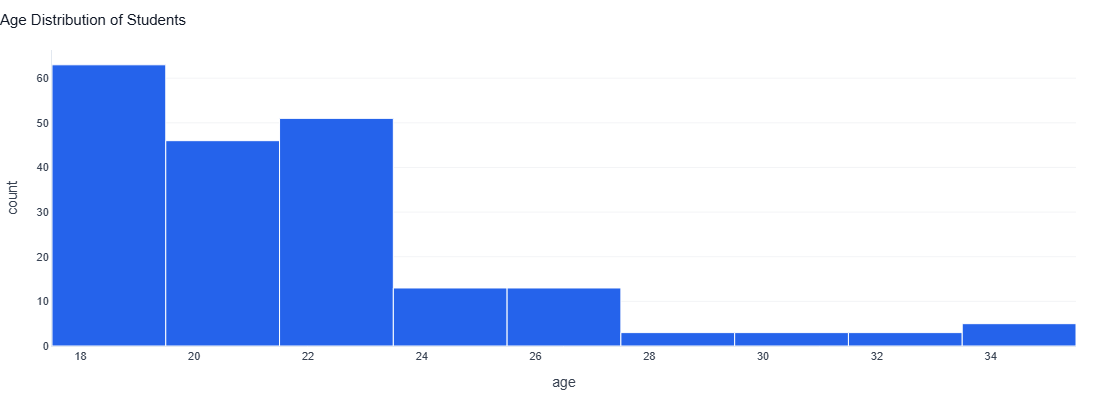

In [8]:
# Age Distribution
fig = px.histogram(students, x='age', nbins=15,
                   color_discrete_sequence=[PALETTE['primary']])
fig.update_traces(marker_line_color='white', marker_line_width=1)
clean_layout(fig, 'Age Distribution of Students')
fig.show()

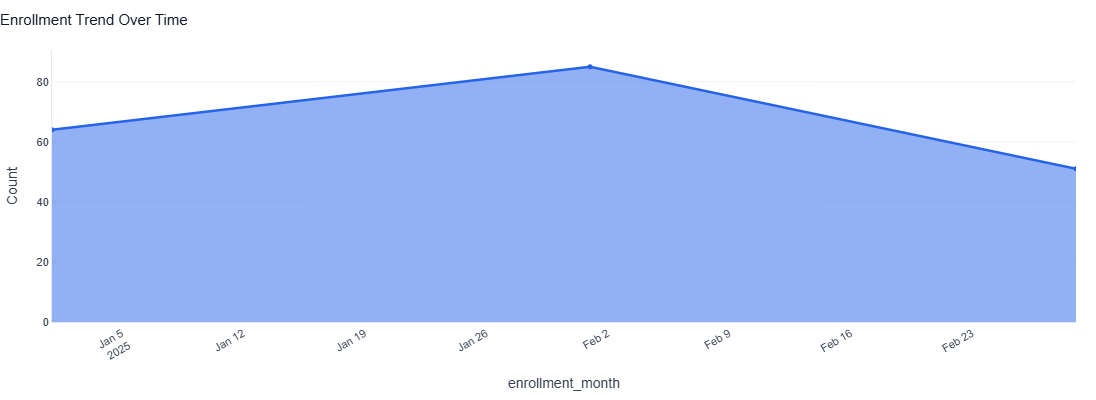

In [9]:
# Enrollment Trend Over Time
enroll_trend = (students.groupby('enrollment_month').size()
                .reset_index(name='Count').sort_values('enrollment_month'))
fig = px.area(enroll_trend, x='enrollment_month', y='Count',
              color_discrete_sequence=[PALETTE['primary']], markers=True)
fig.update_traces(line_width=2.5, marker_size=5)
clean_layout(fig, 'Enrollment Trend Over Time')
fig.update_xaxes(tickangle=-30)
fig.show()

In [10]:
# Course Duration Preference
dur_counts = students['duration'].value_counts().reset_index()
dur_counts.columns = ['Duration', 'Students']
fig = px.pie(dur_counts, names='Duration', values='Students', hole=0.5,
             color_discrete_sequence=[PALETTE['primary'], PALETTE['secondary'], PALETTE['accent']])
fig.update_traces(textposition='outside', textinfo='percent+label',
                  marker=dict(line=dict(color='white', width=2)))
clean_layout(fig, 'Course Duration Preference')
fig.show()

## 🗂️ 5. Raw Student Data

In [11]:
print('=== Students Dataset ===')
display(students.reset_index(drop=True))

=== Students Dataset ===


,student_id,student_name,age,education_level,course,duration,mode,enrollment_date,internship,batch_id,enrollment_month
0,STU0001,Kiran,35,Working Professional,MERN Stack Development,6 Months,Online,2025-01-02,No,B04,2025-01
1,STU0002,Tanya,19,UG,Data Science with Python,1 Month,Online,2025-01-02,FGYP Internship,B02,2025-01
2,STU0003,Faisal,34,Working Professional,Data Science with Python,3 Months,Offline,2025-01-02,No,A03,2025-01
3,STU0004,Ajay,18,UG,Python Full Stack Development,3 Months,Offline,2025-01-02,No,A07,2025-01
4,STU0005,Rahul,22,PG,MERN Stack Development,6 Months,Offline,2025-01-03,No,A01,2025-01
...,...,...,...,...,...,...,...,...,...,...,...
195,STU0196,Aisha,19,UG,UI/UX Design,3 Months,Online,2025-03-13,No,B03,2025-03
196,STU0197,Aisha,23,UG,Data Science with Python,6 Months,Offline,2025-03-13,No,A02,2025-03
197,STU0198,Sahil,35,Working Professional,React Frontend Developer,3 Months,Offline,2025-03-13,No,A02,2025-03
198,STU0199,Imran,19,UG,Data Science with Python,3 Months,Offline,2025-03-14,No,A02,2025-03
